In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns


In [2]:
def assign_drop_sets(set_1, set_2, type_marca, cant_marca_set_1):
    list_muestras = set_2[set_2['Marca'] == type_marca]
    index_test = list_muestras.index[0]
            
    muestra_drop_set_2 = set_2.loc[index_test]
    set_2 = set_2.drop(index=index_test)
            
    key_remplace_set_1 = None
    for key_, value_ in cant_marca_set_1.items():
        if value_ > 1:
            key_remplace_set_1 = key_
            cant_marca_set_1[key_] -= 1
            break

    index_train = set_1[set_1['Marca'] == key_remplace_set_1].index[0]
    muestra_drop_set_1 = set_1.loc[index_train]

    set_1 = set_1.drop(index=index_train)

    set_1 = pd.concat([set_1, muestra_drop_set_2], axis=0)
    set_2 = pd.concat([set_2, muestra_drop_set_1], axis=0)

    return set_1, set_2, cant_marca_set_1

def variability_set(set_1, set_2, original_df, cat_unicas, condition):
    type_marca_types = original_df['Marca'].unique()
    
    cant_marca_set_1 = set_1['Marca'].value_counts().to_dict()

    for type_marca in type_marca_types:

        if type_marca not in set_1['Marca'].values:

            if type_marca in cat_unicas:
                if condition == True:
                    set_1, set_2, cant_marca_set_1 = assign_drop_sets(set_1, set_2, type_marca, cant_marca_set_1)
            else:
                set_1, set_2, cant_marca_set_1 = assign_drop_sets(set_1, set_2, type_marca, cant_marca_set_1)

    return set_1, set_2

df = pd.read_csv("pf_suvs_i302_1s2024.csv")

df.loc[df['Marca'] == 'DS7', 'Marca'] = 'DS'
df.loc[df['Marca'] == 'DS AUTOMOBILES', 'Marca'] = 'DS'
df.loc[df['Marca'] == 'DS7', 'Marca'] = '7'
df.loc[df['Marca'] == 'Jetur', 'Marca'] = 'Jetour'
df.loc[df['Título'] == 'Jetur X70 1.5 Lt At', 'Título'] = 'Jetour X70 1.5 Lt At'
df.loc[df['Marca'] == 'hiunday', 'Marca'] = 'Hyundai'

X = df.drop(['Precio'], axis=1)
Y = df['Precio']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

# Volver a unir X_train y Y_train en un solo DataFrame para train y test
set_train = pd.concat([X_train, Y_train], axis=1)
set_test = pd.concat([X_test, Y_test], axis=1)

cat_unicas = df['Marca'].value_counts()[df['Marca'].value_counts() == 1].index.tolist()
print(cat_unicas)
set_train, set_test = variability_set(set_train, set_test, df, cat_unicas, True) 

['Abarth', 'Sandero']


In [3]:
print(set_train.shape[0] + set_test.shape[0])
print(df.shape[0])


22377
22377


In [4]:
df['Marca'].value_counts()

Marca
Jeep             3099
Ford             2606
Volkswagen       2250
Renault          2202
Chevrolet        2101
Toyota           1906
Honda            1019
Peugeot           906
Citroën           850
Audi              839
BMW               637
Fiat              615
Hyundai           574
Mercedes-Benz     505
Kia               448
Chery             341
Nissan            311
Dodge             272
Suzuki            138
Land Rover        132
BAIC               98
Porsche            94
Mitsubishi         80
Subaru             72
Volvo              63
DS                 33
Alfa Romeo         26
Isuzu              24
Haval              23
Lexus              23
Lifan              16
Geely              14
Ssangyong          14
Jetour             13
Daihatsu           12
MINI                9
JAC                 6
Jaguar              4
Abarth              1
Sandero             1
Name: count, dtype: int64

In [5]:
set_train['Marca'].value_counts()

Marca
Jeep             2789
Ford             2322
Volkswagen       2008
Renault          2003
Chevrolet        1900
Toyota           1711
Honda             932
Peugeot           816
Citroën           762
Audi              744
BMW               567
Fiat              552
Hyundai           519
Mercedes-Benz     452
Kia               405
Chery             316
Nissan            272
Dodge             251
Suzuki            125
Land Rover        125
BAIC               91
Porsche            89
Mitsubishi         72
Subaru             61
Volvo              57
DS                 29
Alfa Romeo         25
Lexus              22
Isuzu              22
Haval              21
Geely              13
Lifan              13
Ssangyong          13
Daihatsu           11
Jetour             10
MINI                7
JAC                 6
Jaguar              4
Abarth              1
Sandero             1
Name: count, dtype: int64

In [6]:
set_test['Marca'].value_counts()

Marca
Jeep             310
Ford             284
Volkswagen       242
Chevrolet        201
Renault          199
Toyota           195
Audi              95
Peugeot           90
Citroën           88
Honda             87
BMW               70
Fiat              63
Hyundai           55
Mercedes-Benz     53
Kia               43
Nissan            39
Chery             25
Dodge             21
Suzuki            13
Subaru            11
Mitsubishi         8
Land Rover         7
BAIC               7
Volvo              6
Porsche            5
DS                 4
Lifan              3
Jetour             3
Isuzu              2
Haval              2
MINI               2
Alfa Romeo         1
Lexus              1
Daihatsu           1
Geely              1
Ssangyong          1
Name: count, dtype: int64

In [7]:
set_test['Marca'].unique()


array(['Jeep', 'Toyota', 'Ford', 'Honda', 'Renault', 'Land Rover', 'Audi',
       'Peugeot', 'Hyundai', 'Nissan', 'Citroën', 'Chery', 'Volkswagen',
       'Kia', 'Chevrolet', 'BMW', 'Alfa Romeo', 'Fiat', 'Subaru', 'Volvo',
       'Mercedes-Benz', 'Isuzu', 'Suzuki', 'Porsche', 'Mitsubishi',
       'Dodge', 'DS', 'Lexus', 'Lifan', 'Jetour', 'BAIC', 'Haval',
       'Daihatsu', 'MINI', 'Geely', 'Ssangyong'], dtype=object)

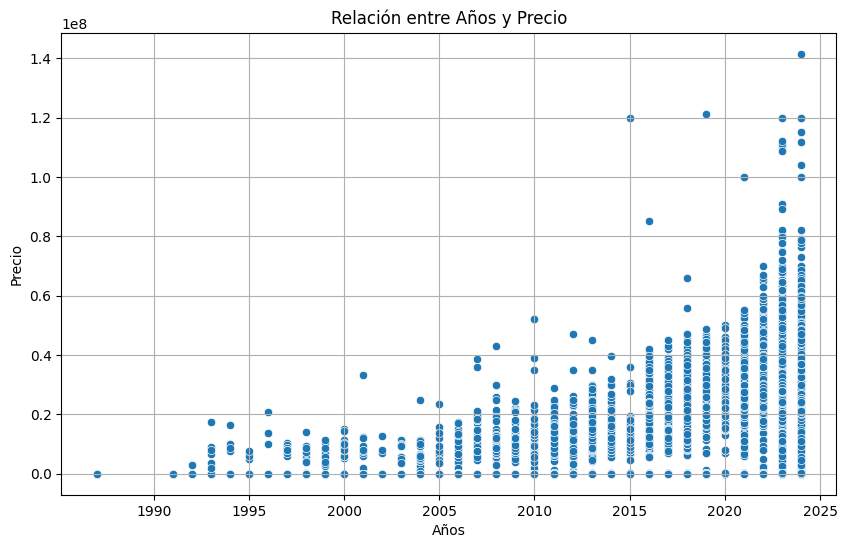

In [8]:
import matplotlib.pyplot as plt

df.loc[df['Año'] == 436707, 'Año'] = 2012
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Año', y='Precio', data=df)
plt.title('Relación entre Años y Precio')
plt.xlabel('Años')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

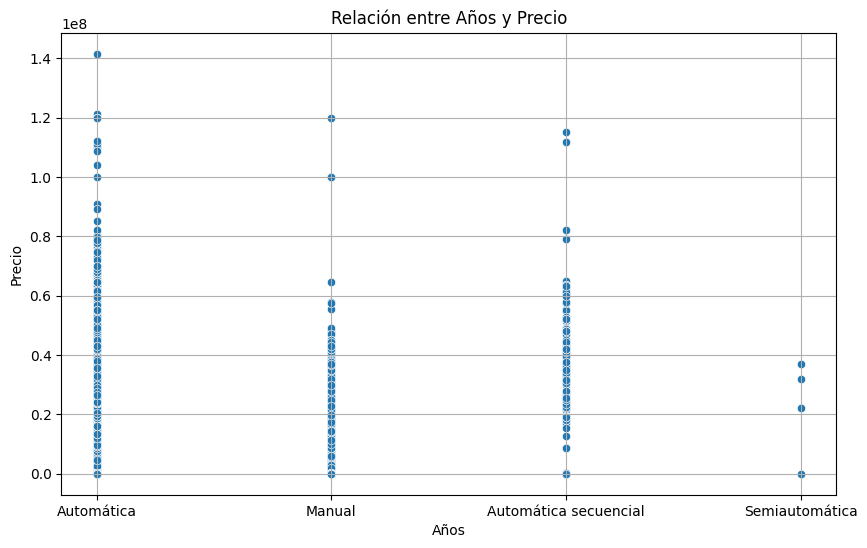

In [14]:
df.loc[df['Año'] == 436707, 'Año'] = 2012
df = df[df["Puertas"] < 10]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tipo de combustible', y='Precio', data=df)
plt.title('Relación entre Años y Precio')
plt.xlabel('Años')
plt.ylabel('Precio')
plt.grid(True)
plt.show()